# Mine-Subsidence Early-Warning — Full Run & Score

Runs the **entire** `src/minesub/` pipeline top to bottom from the live data sources, then reports the
**accuracy of both models at the end**.

```
CA DWR displacement  ┐
Open-Meteo weather    ├─► timeseries ─► features ─► labels ─► temporal split ─► train GBDT + LSTM ─► ACCURACY
(synthetic fallback)  ┘
```

Every cell is a single pipeline stage. Re-run top-to-bottom (`Kernel ▸ Restart & Run All`) for a clean rebuild.
The headline numbers are in the **last** section (§8).

## 1 — Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ.setdefault("OMP_NUM_THREADS", "4")

ROOT = Path().resolve()
while not (ROOT / "src" / "minesub").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try: get_ipython().run_line_magic("matplotlib", "inline")
except Exception: pass
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)

from minesub.config import load_config
cfg = load_config(); cfg.ensure_dirs()
PROC = cfg.paths["processed"]
print("repo root :", ROOT)
print("python    :", sys.version.split()[0])
print("config    :", cfg.path)
print("window    :", cfg["features"]["backward_window_days"], "d back  /",
      cfg["features"]["forward_horizon_days"], "d forward   | label:", cfg["labels"]["method"])

repo root : /Users/anand/Documents/dev/SIH
python    : 3.11.16
config    : /Users/anand/Documents/dev/SIH/config/config.yaml
window    : 30 d back  / 21 d forward   | label: quantile


## 2 — Collect from source

`load_ground_displacement` → CA DWR CKAN (`data.ca.gov`); `load_weather` → Open-Meteo archive API, one call per
station (responses cached under `data/raw/weather/`). If a source is unreachable, a labelled **synthetic
surrogate** with the same schema is returned and every row is tagged `data_source="synthetic_fallback"` — §8
checks for that.

In [2]:
from minesub.data.sources import load_ground_displacement, load_weather

t0 = time.time()
disp = load_ground_displacement(cfg)
stations = disp.groupby("station_id")[["lat", "lon"]].first().reset_index()
wx = load_weather(cfg, stations)
print(f"\ncollected in {time.time()-t0:.1f}s")
print("displacement :", disp.shape, "|", disp["station_id"].nunique(), "stations |",
      "source:", sorted(disp["data_source"].unique()))
print("weather      :", wx.shape, "| source:", sorted(wx["data_source"].unique()))
display(disp.head(3)); display(wx.head(3))

22:39:31  INFO     minesub.data.sources  CA DWR timeseries resource 'Ground Surface Displacement - Daily Mean': (98602, 4)


22:39:33  INFO     minesub.data.sources  joined station coords (11 stations)


22:39:33  INFO     minesub.data.sources  QC filter kept 87880 / 93577 rows


22:39:33  INFO     minesub.data.sources  displacement unit scale -> mm: x304.8 (99p span=1.29 raw)


22:39:33  INFO     minesub.data.sources  CA DWR feed: 87880 rows, 11 stations


22:39:33  INFO     minesub.data.sources  weather: 139194 rows; stations by source: {'open-meteo': 11}



collected in 6.7s
displacement : (87880, 6) | 11 stations | source: ['ca_dwr']
weather      : (139194, 6) | source: ['open-meteo']


,station_id,date,lat,lon,settlement_mm,data_source
0,09N03E08C004M,1992-01-25,38.64643,-121.667384,-0.0000,ca_dwr
1,09N03E08C004M,1992-01-26,38.64643,-121.667384,-0.0000,ca_dwr
2,09N03E08C004M,1992-01-27,38.64643,-121.667384,-0.3048,ca_dwr


,station_id,date,temp_c,humidity_pct,rain_mm,data_source
0,09N03E08C004M,1992-01-01,7.1,82,0.0,open-meteo
1,09N03E08C004M,1992-01-02,6.8,78,0.0,open-meteo
2,09N03E08C004M,1992-01-03,6.9,77,0.0,open-meteo


## 3 — Build the per-station daily timeseries  (resample + derived tilt + weather join)

In [3]:
from minesub.data.build import build_timeseries
ts = build_timeseries(cfg, save=True)
print("\ntimeseries :", ts.shape, "|", ts["station_id"].nunique(), "stations |",
      ts["date"].min().date(), "->", ts["date"].max().date())
print("disp source(s):", sorted(ts["data_source_disp"].unique()),
      "| wx source(s):", sorted(ts["data_source_wx"].unique()))
display(ts.head(3))

22:39:37  INFO     minesub.data.sources  CA DWR timeseries resource 'Ground Surface Displacement - Daily Mean': (98602, 4)


22:39:39  INFO     minesub.data.sources  joined station coords (11 stations)


22:39:39  INFO     minesub.data.sources  QC filter kept 87880 / 93577 rows


22:39:39  INFO     minesub.data.sources  displacement unit scale -> mm: x304.8 (99p span=1.29 raw)


22:39:39  INFO     minesub.data.sources  CA DWR feed: 87880 rows, 11 stations


...

22:39:39  INFO     minesub.data.build  timeseries: 96801 rows, 11 stations, 1992-10-21 -> 2026-08-18


22:39:39  INFO     minesub.data.build  displacement source(s): ['ca_dwr'] | weather source(s): ['open-meteo']


22:39:39  INFO     minesub.data.build  wrote /Users/anand/Documents/dev/SIH/data/processed/timeseries.parquet



timeseries : (96801, 11) | 11 stations | 1992-10-21 -> 2026-08-18
disp source(s): ['ca_dwr'] | wx source(s): ['open-meteo']


,station_id,date,distance_mm,lat,lon,data_source_disp,tilt_deg,temp_c,humidity_pct,rain_mm,data_source_wx
0,09N03E08C004M,1992-10-21,24.0792,38.64643,-121.667384,ca_dwr,-0.002093,18.8,77,13.0,open-meteo
1,09N03E08C004M,1992-10-22,23.4696,38.64643,-121.667384,ca_dwr,0.001020,17.9,65,0.0,open-meteo
2,09N03E08C004M,1992-10-23,23.1648,38.64643,-121.667384,ca_dwr,-0.000221,19.0,57,0.0,open-meteo


## 4 — Feature engineering  (backward 30-day window → feature vector; forward 21-day horizon → target signals)

In [4]:
from minesub.features import build_feature_table, feature_columns
samples = build_feature_table(cfg, ts=ts, save=True)
feat_cols = feature_columns(samples)
print("\nsamples :", samples.shape, "|", len(feat_cols), "model features")
print(feat_cols)

22:39:49  INFO     minesub.features  feature table: 13754 samples, 11 stations, 1992-11-19 -> 2026-07-26


22:39:49  INFO     minesub.features  wrote /Users/anand/Documents/dev/SIH/data/processed/samples.parquet



samples : (13754, 33) | 25 model features
['days_since_start', 'distance_last', 'distance_delta', 'distance_rate', 'distance_accel', 'distance_std', 'distance_range', 'tilt_last', 'tilt_delta', 'tilt_rate', 'tilt_accel', 'tilt_std', 'tilt_abs_last', 'humidity_mean', 'humidity_delta', 'humidity_std', 'temp_mean', 'temp_range', 'temp_std', 'rain_sum', 'rain_max', 'rain_recent7', 'rain_days', 'doy_sin', 'doy_cos']


## 5 — Labels  (composite hazard score → safe / watch / critical)

In [5]:
from minesub.labels import add_risk_labels
from minesub import RISK_CLASSES
labeled = add_risk_labels(cfg, samples, save=True)
counts = labeled["risk_class"].value_counts().reindex(RISK_CLASSES)
print("\nclass counts :", {k: int(v) for k, v in counts.items()},
      " shares:", {k: f"{v/len(labeled):.1%}" for k, v in counts.items()})

22:39:49  INFO     minesub.labels  label method=quantile  distribution: {'safe': 8252, 'watch': 4126, 'critical': 1376}


22:39:49  INFO     minesub.labels  wrote /Users/anand/Documents/dev/SIH/data/processed/samples_labeled.parquet



class counts : {'safe': 8252, 'watch': 4126, 'critical': 1376}  shares: {'safe': '60.0%', 'watch': '30.0%', 'critical': '10.0%'}


## 6 — Temporal split  (earliest 65% train · next 15% val · latest 20% test)

In [6]:
from minesub.datasplit import temporal_split
tr, va, te = temporal_split(cfg, labeled)
y = labeled["y"].to_numpy()
for nm, m in [("train", tr), ("val", va), ("test", te)]:
    span = labeled.loc[m, "t"]
    d_ = pd.Series(y[m]).value_counts().reindex(range(3)).fillna(0).astype(int).tolist()
    print(f"{nm:5s} n={m.sum():4d}  {span.min().date()} -> {span.max().date()}  [safe,watch,critical]={d_}")

22:39:49  INFO     minesub.datasplit  split: train=8940 (<2017-12-10)  val=2063  test=2751 (>=2021-07-16)


train n=8940  1992-11-19 -> 2017-12-10  [safe,watch,critical]=[5393, 2671, 876]
val   n=2063  2017-12-10 -> 2021-07-16  [safe,watch,critical]=[1308, 552, 203]
test  n=2751  2021-07-16 -> 2026-07-26  [safe,watch,critical]=[1551, 903, 297]


## 7 — Train both models

`train(cfg, name)` re-reads the labelled samples, re-applies the temporal split, fits, scores the **held-out test
split**, and writes `artifacts/models/` + `reports/metrics_<name>.json`.

* **GBDT** — `HistGradientBoostingClassifier`, 3-class, class-balanced, early stopping, on the ~24-dim feature vector.
* **LSTM** — 2-layer LSTM (hidden 64) + MLP head, on the raw `[30, 4]` window; keeps the best val-macro-F1 epoch.

In [7]:
from minesub.train import train
metrics = {}
for name in ("gbdt", "torch"):
    print(f"\n{'='*64}\n  TRAIN  {name}\n{'='*64}")
    metrics[name] = train(cfg, name)
try: get_ipython().run_line_magic("matplotlib", "inline")   # train() flips mpl to Agg
except Exception: pass


  TRAIN  gbdt


22:39:51  INFO     minesub.datasplit  split: train=8940 (<2017-12-10)  val=2063  test=2751 (>=2021-07-16)


22:39:52  INFO     minesub.models.gbdt  trained; n_iter=90 (of max 600)


22:39:54  INFO     minesub.models.gbdt  saved -> /Users/anand/Documents/dev/SIH/artifacts/models/gbdt.joblib


22:39:54  INFO     minesub.train  top features:
distance_rate       0.087950
distance_std        0.033602
distance_last       0.028726
distance_accel      0.026030
doy_sin             0.024137
distance_range      0.018578
doy_cos             0.009123
humidity_mean       0.004870
days_since_start    0.004178
rain_max            0.002134


...

22:40:08  INFO     minesub.models.torch  done; best val macro-F1=0.542  device=mps


22:40:08  INFO     minesub.models.torch  saved -> /Users/anand/Documents/dev/SIH/artifacts/models/lstm.pt


22:40:08  INFO     minesub.evaluate  wrote /Users/anand/Documents/dev/SIH/reports/confusion_torch.png


22:40:08  INFO     minesub.evaluate  [torch] acc=0.624  macro-F1=0.518  recall(critical)=0.266  PR-AUC(critical)=0.239


22:40:08  INFO     minesub.evaluate  wrote /Users/anand/Documents/dev/SIH/reports/metrics_torch.json


## 8 — 📊 Accuracy & results

Held-out **test** split only (windows that end *after* everything the models trained on).

`accuracy` = fraction of the 3 classes predicted correctly. The classes are imbalanced (~60 / 30 / 10), so a
"always predict `safe`" baseline already scores ~0.60 — **`macro_f1`** (unweighted mean F1 across the 3 classes,
random-chance floor 0.33) and **`recall_critical`** (share of truly-critical windows caught) are the metrics that
show the model does more than guess the majority class.

In [8]:
base = counts.max() / counts.sum()          # majority-class ("always safe") baseline accuracy
rng_f1 = 1/3

rows = {}
for name, m in metrics.items():
    rows[name] = {
        "test samples":        m["n_samples"],
        "ACCURACY":            round(m["accuracy"], 4),
        "  vs baseline":       f'{m["accuracy"] - base:+.4f}',
        "macro_f1":            round(m["macro_f1"], 4),
        "macro_precision":     round(m["macro_precision"], 4),
        "macro_recall":        round(m["macro_recall"], 4),
        "recall_critical":     round(m["recall_critical"], 4),
        "precision_critical":  round(m["precision_critical"], 4),
        "PR_AUC_critical":     round(m["pr_auc_ovr"]["critical"], 4),
        "synthetic_data":      m.get("synthetic_data"),
    }
summary = pd.DataFrame(rows).T
print(f"majority-class baseline accuracy : {base:.4f}   (always predict '{counts.idxmax()}')")
print(f"random-chance macro-F1           : {rng_f1:.4f}\n")
summary

majority-class baseline accuracy : 0.6000   (always predict 'safe')
random-chance macro-F1           : 0.3333



,test samples,ACCURACY,vs baseline,macro_f1,macro_precision,macro_recall,recall_critical,precision_critical,PR_AUC_critical,synthetic_data
gbdt,2751,0.6358,+0.0358,0.5109,0.5222,0.509,0.1785,0.2849,0.2083,False
torch,2751,0.6238,+0.0238,0.5178,0.5164,0.5202,0.266,0.229,0.2389,False


In [9]:
best = max(metrics, key=lambda k: metrics[k]["accuracy"])
m = metrics[best]
print("="*64)
print(f"  HEADLINE  —  best model: {best.upper()}")
print("="*64)
print(f"  accuracy         : {m['accuracy']*100:5.1f}%   (baseline {base*100:.1f}%)")
print(f"  macro-F1         : {m['macro_f1']:.3f}    (chance 0.333)")
print(f"  critical recall  : {m['recall_critical']*100:5.1f}%   <- share of real hazards caught")
print(f"  critical prec.   : {m['precision_critical']*100:5.1f}%")
print(f"  data             : {'REAL (CA DWR + Open-Meteo)' if not m.get('synthetic_data') else 'SYNTHETIC FALLBACK — not a benchmark'}")
print("="*64)
if m.get("synthetic_data"):
    print("  !! a data source was unreachable; rerun §2 with a connection for real numbers")

  HEADLINE  —  best model: GBDT
  accuracy         :  63.6%   (baseline 60.0%)
  macro-F1         : 0.511    (chance 0.333)
  critical recall  :  17.8%   <- share of real hazards caught
  critical prec.   :  28.5%
  data             : REAL (CA DWR + Open-Meteo)


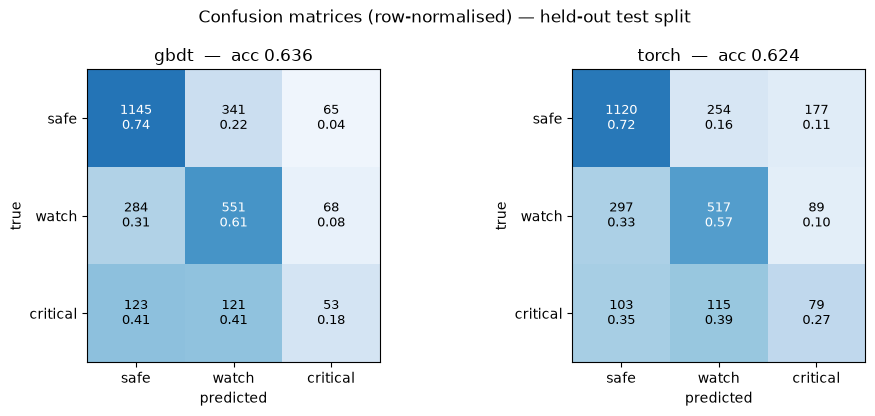

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, name in zip(axes, ("gbdt", "torch")):
    cm = np.array(metrics[name]["confusion_matrix"], float)
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3), RISK_CLASSES); ax.set_yticks(range(3), RISK_CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{name}  —  acc {metrics[name]['accuracy']:.3f}")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{int(cm[i,j])}\n{cmn[i,j]:.2f}", ha="center", va="center",
                    color="white" if cmn[i, j] > .5 else "black", fontsize=9)
fig.suptitle("Confusion matrices (row-normalised) — held-out test split")
plt.tight_layout(); plt.show()

In [11]:
summary.to_csv(cfg.paths["reports"] / "run_and_score_summary.csv")
print("saved ->", cfg.paths["reports"] / "run_and_score_summary.csv")
print("\nper-model metrics JSON: reports/metrics_gbdt.json , reports/metrics_torch.json")
print("saved models         : artifacts/models/gbdt.joblib , artifacts/models/lstm.pt")

saved -> /Users/anand/Documents/dev/SIH/reports/run_and_score_summary.csv

per-model metrics JSON: reports/metrics_gbdt.json , reports/metrics_torch.json
saved models         : artifacts/models/gbdt.joblib , artifacts/models/lstm.pt
